## Question 1: Frailty

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for d in ["src", "data/raw", "data/processed", "results/figures", "results/reports"]:
    os.makedirs(d, exist_ok=True)

In [ ]:
raw_df = pd.read_csv("data/raw/raw_yield_data.csv")
raw_df

,Height,Weight,Age,Grip Strength,Frailty
0,65.8,112,30,30,N
1,71.5,136,19,31,N
2,69.4,153,45,29,N
3,68.2,142,22,28,Y
4,67.8,144,29,24,Y
5,68.7,123,50,26,N
6,69.8,141,51,22,Y
7,70.1,136,23,20,Y
8,67.9,112,17,19,N
9,66.8,120,39,31,N


### Unit Standardization, Feature Engineering, and Categorical -> Numeric Encoding

In [ ]:
df = raw_df.copy()

# Height in inches -> Height in meters
df["Height_m"] = df["Height"] * 0.0254

# Weight in lbs -> Weight in kilogeams
df["Weight_kg"] = df["Weight"] * 0.45359237

# BMI Calculation
df["BMI"] = (df["Weight_kg"] / df["Height_m"] ** 2).round(2)

# Age group categorization
def age_group(age):
    if age < 30:
        return "<30"
    elif age <= 45:
        return "30-45"
    elif age <= 60:
        return "46-60"
    else:
        return ">60"
df["AgeGroup"] = df["Age"].apply(age_group)

# Frailty to Binary
df["Frailty_binary"] = (df["Frailty"] == "Y").astype("int8")

# One-hot encode AgeGroup
ages_encoded = pd.get_dummies(df["AgeGroup"], prefix="AgeGroup").astype("int8")
df = pd.concat([df, ages_encoded], axis=1)

df.to_csv("data/processed/processed_data.csv", index=False)
df

,Height,Weight,Age,Grip Strength,Frailty,Height_m,Weight_kg,BMI,AgeGroup,Frailty_binary,AgeGroup_30-45,AgeGroup_46-60,AgeGroup_<30
0,65.8,112,30,30,N,1.67132,50.802345,18.19,30-45,0,1,0,0
1,71.5,136,19,31,N,1.81610,61.688562,18.70,<30,0,0,0,1
2,69.4,153,45,29,N,1.76276,69.399633,22.33,30-45,0,1,0,0
3,68.2,142,22,28,Y,1.73228,64.410117,21.46,<30,1,0,0,1
4,67.8,144,29,24,Y,1.72212,65.317301,22.02,<30,1,0,0,1
5,68.7,123,50,26,N,1.74498,55.791862,18.32,46-60,0,0,1,0
6,69.8,141,51,22,Y,1.77292,63.956524,20.35,46-60,1,0,1,0
7,70.1,136,23,20,Y,1.78054,61.688562,19.46,<30,1,0,0,1
8,67.9,112,17,19,N,1.72466,50.802345,17.08,<30,0,0,0,1
9,66.8,120,39,31,N,1.69672,54.431084,18.91,30-45,0,1,0,0


### EDA & Reporting

In [ ]:
summary = df[["Height_m", "Weight_kg", "Age", "Grip Strength", "BMI"]].agg(["mean", "median", "std"]).round(2)
summary

,Height_m,Weight_kg,Age,Grip Strength,BMI
mean,1.74,59.83,32.50,26.00,19.68
median,1.74,61.69,29.50,27.00,19.19
std,0.04,6.46,12.86,4.52,1.78


In [26]:
correlation = df["Grip Strength"].corr(df["Frailty_binary"])
print(f"correlation between Grip and Frailty: r = {correlation:.2f}")

with open("results/reports/Q1_findings.md", "w") as f:
    f.write("## Summary statistics\n")
    f.write(summary.to_markdown())
    f.write("\n\n### Correlation r = -0.48\n")
    f.write("\n\nSince it has negative correlation, it can be said that grip strength is somewhat correlated to frailty.")

correlation between Grip and Frailty: r = -0.48


## Question 2: Data Visualization

In [ ]:
student_df = pd.read_csv("data/raw/StudentsPerformance.csv")
student_df.head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75
5,female,group B,associate's degree,standard,none,71,83,78
6,female,group B,some college,standard,completed,88,95,92
7,male,group B,some college,free/reduced,none,40,43,39
8,male,group D,high school,free/reduced,completed,64,64,67
9,female,group B,high school,free/reduced,none,38,60,50


In [ ]:
print(student_df.isna().sum())

student_df[student_df.isna().any(axis=1)].head()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score


In [ ]:
student_df["math score"] = student_df["math score"].fillna(student_df["math score"].median())
student_df["reading score"] = student_df["reading score"].fillna(student_df["reading score"].median())
student_df["writing score"] = student_df["writing score"].fillna(student_df["writing score"].median())

# Student average
student_df["overall_avg"] = student_df[["math score", "reading score", "writing score"]].mean(axis=1).round(2)

student_df.to_csv("data/processed/processed_student.csv", index=False)
student_df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,overall_avg
0,female,group B,bachelor's degree,standard,none,72,72,74,72.67
1,female,group C,some college,standard,completed,69,90,88,82.33
2,female,group B,master's degree,standard,none,90,95,93,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.33
4,male,group C,some college,standard,none,76,78,75,76.33


### V1 — Gender boxplots (math vs reading)

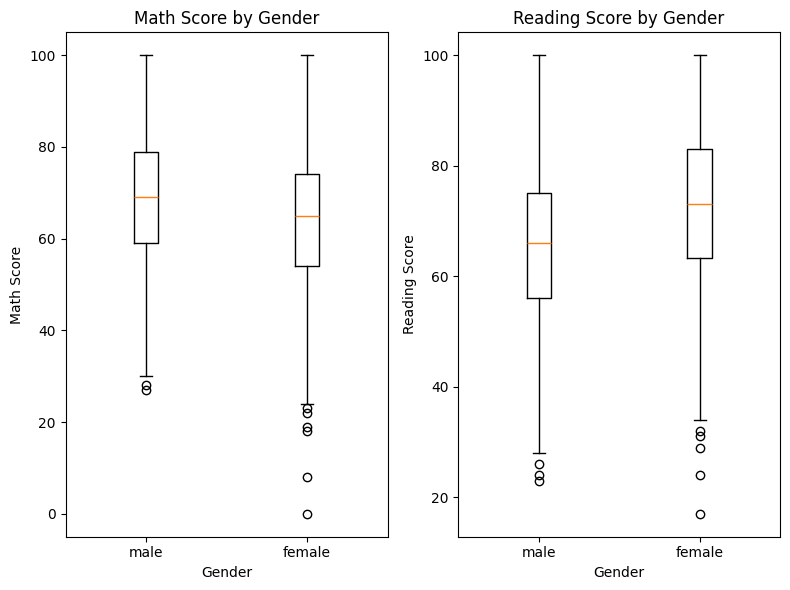

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))

# Math plot
male_math = student_df.loc[student_df["gender"] == "male", "math score"]
female_math = student_df.loc[student_df["gender"] == "female", "math score"]
axes[0].boxplot([male_math, female_math], tick_labels=["male", "female"])
axes[0].set_title("Math Score by Gender")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Math Score")

# Reading plot
male_read = student_df.loc[student_df["gender"] == "male", "reading score"]
female_read = student_df.loc[student_df["gender"] == "female", "reading score"]
axes[1].boxplot([male_read, female_read], tick_labels=["male", "female"])
axes[1].set_title("Reading Score by Gender")
axes[1].set_xlabel("Gender")
axes[1].set_ylabel("Reading Score")

plt.tight_layout()
plt.savefig("results/figures/v1_gender_boxplots.png", dpi=300)
plt.show()

### Question: Are there gender differences in math vs reading?

It looks like male students have a little higher median in the Math score, but females have a higher score when it comes to reading. However, the spread seems to be quite wide for both genders, so the difference is relatively small in comparison to each student. At the same time, there are more lower outliers on the female side in comparison to the male side on both math and reading. The bottom whisker for male reading is a bit lower than for male math, and males have more lower outliers in reading (3) than in math (2). Overall though, it seems that reading is a lower score in general than math as it shows students score less in reading compared to math.

--------

### V2 — Test prep impact on math

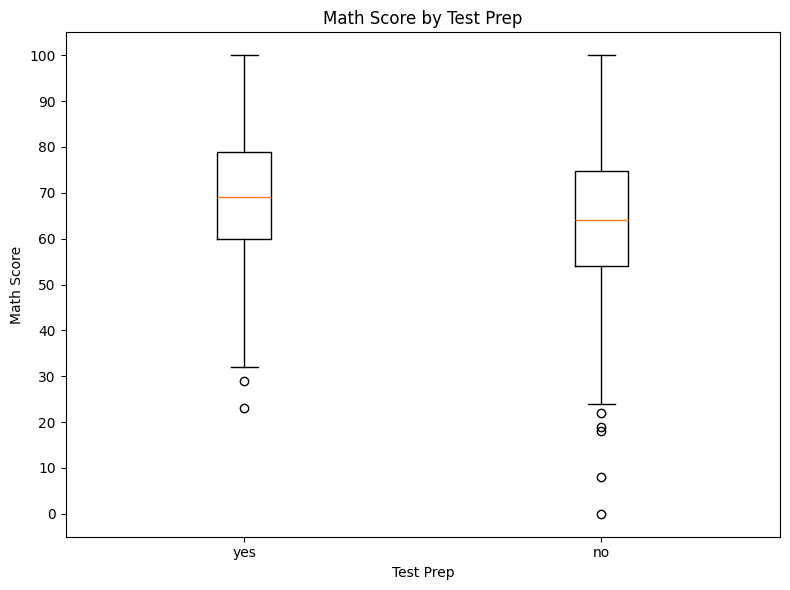

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

completed = student_df.loc[student_df["test preparation course"] == "completed", "math score"]
none = student_df.loc[student_df["test preparation course"] == "none", "math score"]
ax.boxplot([completed, none], tick_labels=["yes", "no"])
ax.set_title("Math Score by Test Prep")
ax.set_xlabel("Test Prep")
ax.set_ylabel("Math Score")
ax.set_yticks(range(0, 101, 10))

plt.tight_layout()
plt.savefig("results/figures/v2_testprep_impact.png", dpi=300)
plt.show()

### Question: Do students who completed test prep score higher in math?

Students that completed any test prep have a higher score then those students who didn't take any test prep. It can be seen with the box and whisker plot, where the median line is slightly higher on the "Yes", completed side, in comparison to the "No", none side. The completed group averaged around 69 in math compated to the no test prep group's 64, so the gap is not huge, but still noticeable. While the boxes for each overlap one another a good amount, the no test group has noticeable outliers towards the bottom part, so test prep is not the only thing separating a high scorer vs a low one. It could be that students how are more motivated to do well will take a test prep course, thus having a closer total average in comparison to the students who did not take any courses.

--------------

### V3 — Lunch type and average performance

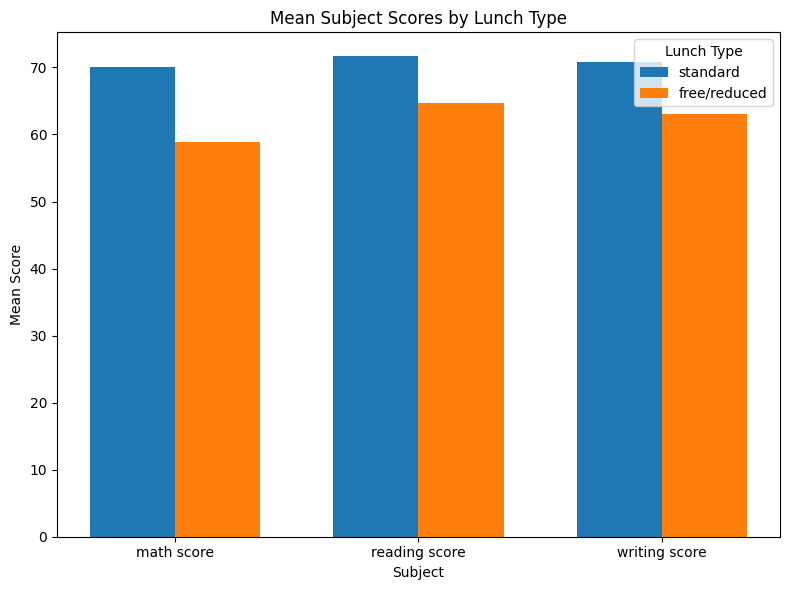

In [ ]:
lunch_avg = student_df.groupby("lunch")[["math score", "reading score", "writing score"]].mean()

subjects = ["math score", "reading score", "writing score"]
x = np.arange(len(subjects))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(x - width / 2, lunch_avg.loc["standard", subjects], width, label="standard")
ax.bar(x + width / 2, lunch_avg.loc["free/reduced", subjects], width, label="free/reduced")

ax.set_title("Mean Subject Scores by Lunch Type")
ax.set_xlabel("Subject")
ax.set_ylabel("Mean Score")
ax.set_xticks(x)
ax.set_xticklabels(subjects)
ax.legend(title="Lunch Type")

plt.tight_layout()
plt.savefig("results/figures/v3_lunch_average.png", dpi=300)
plt.show()

### Question: Does lunch type (standard vs free/reduced) relate to outcomes?

Students that are the standard/normal lunch plan have a higher average on all 3 subjects than those on the free/reduced lunch plan. Those on the standard lunch plan seem to have about the same average on all three averages, but on the free/reduced lunch, the average math score is a lot lower then the other subjects on free/reduced lunch. THe standard lunch group has an average around 70 in math, 72 in reading, and 71 in writing, while the free/reduced averages around 58, 63, and 65. It is interesting that the gap is not even across all subjects through, since you'd expect the subjects to decrease by the same amount on free/reduced lunch, but this is not the case. Looking at the psychological stand point, it can be said that math requires more brain power for some, and that can be fueled by a good, properly lunch. That side, this is purely observational data and not an experiment, so the lunch type is more likely a proxy for a broader economic status than a direcr cause of lower subject scores.

---

### V4 — Subject correlations

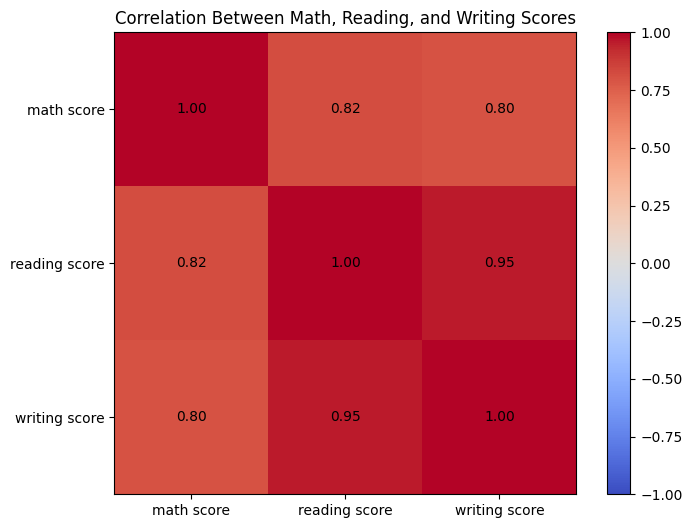

In [ ]:
corr_matrix = student_df[["math score", "reading score", "writing score"]].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns)
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)

for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}", ha="center", va="center", color="black")

ax.set_title("Correlation Between Math, Reading, and Writing Scores")
fig.colorbar(im)

plt.savefig("results/figures/v4_subject_correlation_heatmap.png", dpi=300)
plt.show()

### Question: How strongly do the three subjects move together?

Reading and writing has the most correlation with each other (r = .95), which makes sense since they both language based skills. Math has less of a correlation the two (r = .82 with reading and .80 with writing), which also makes sense since it requires a completely different skillset then reading and writing. That said, the correlation between all three are positive and still strong, so if studnts do well in one subject, they are likely to do well in the others. None of the 3 subject correlations are exactly 1, so students can be stronger in one subject then another. Though, given that the scores are not totally independent, patterns will likely show from one subject to another.

---

### V5 — Math vs reading with trend lines by test prep

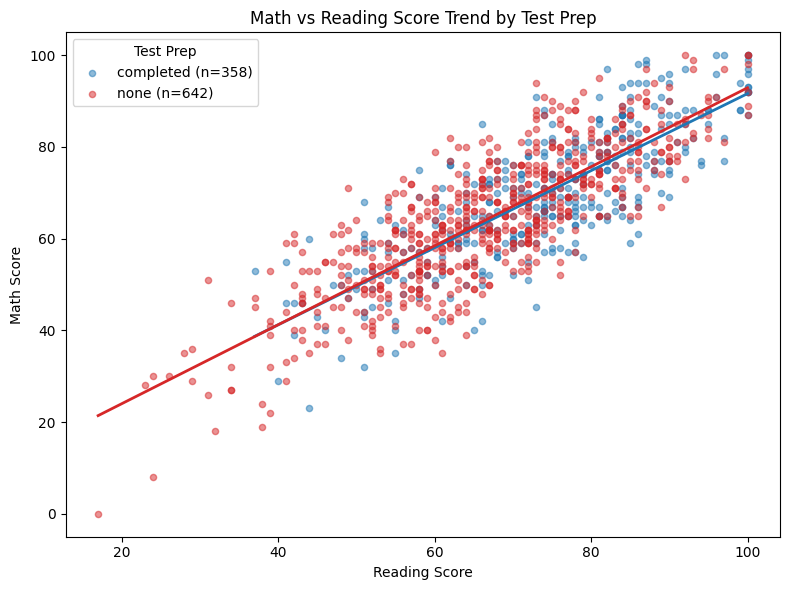

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colors = {"completed": "tab:blue", "none": "tab:red"}
counts = student_df["test preparation course"].value_counts()

for group in ["completed", "none"]:
    sub = student_df[student_df["test preparation course"] == group]
    ax.scatter(sub["reading score"], sub["math score"], alpha=0.5, s=20,
               color=colors[group],
               label=f"{group} (n={counts[group]})")

    slope, intercept = np.polyfit(sub["reading score"], sub["math score"], 1)
    x_line = np.linspace(sub["reading score"].min(), sub["reading score"].max(), 100)
    ax.plot(x_line, slope * x_line + intercept, color=colors[group], linewidth=2)

ax.set_title("Math vs Reading Score Trend by Test Prep")
ax.set_xlabel("Reading Score")
ax.set_ylabel("Math Score")
ax.legend(title="Test Prep")

plt.tight_layout()
plt.savefig("results/figures/v5_math_reading_trend.png", dpi=300)
plt.show()

### Question: How strongly are math and reading scores associated, and do students who completed the test-preparation course have a different slope in the math–reading relationship than those who did not?

The math and reading scores are clearly connected to each other where students who do well in one subject will likely do well in the other. Both lines of best fit are pretty much the same, where towards the beginning of the line, are overlapping one another and only towards the end, do they slightly seperate. The completed test prep group has scores much higher in math on average, but that's comparing the groups overall average, not those with the same reading score. Since the lines are so close and even cross one another, test prep does not really seem to give math a boost the way it shows from the averages. It is more like completed test prep students will also read better, and since reading and math move together, that pulls their math score up too.

---

In [25]:
q2_interpretations = {
    "V1 — Gender boxplots (math vs reading)": """It looks like male students have a little higher median in the Math score, but females have a higher score when it comes to reading. However, the spread seems to be quite wide for both genders, so the difference is relatively small in comparison to each student. At the same time, there are more lower outliers on the female side in comparison to the male side on both math and reading. The bottom whisker for male reading is a bit lower than for male math, and males have more lower outliers in reading (3) than in math (2). Overall though, it seems that reading is a lower score in general than math as it shows students score less in reading compared to math.""",
    "V2 — Test prep impact on math": """Students that completed any test prep have a higher score then those students who didn't take any test prep. It can be seen with the box and whisker plot, where the median line is slightly higher on the "Yes", completed side, in comparison to the "No", none side. The completed group averaged around 69 in math compated to the no test prep group's 64, so the gap is not huge, but still noticeable. While the boxes for each overlap one another a good amount, the no test group has noticeable outliers towards the bottom part, so test prep is not the only thing separating a high scorer vs a low one. It could be that students how are more motivated to do well will take a test prep course, thus having a closer total average in comparison to the students who did not take any courses.""",
    "V3 — Lunch type and average performance": """Students that are the standard/normal lunch plan have a higher average on all 3 subjects than those on the free/reduced lunch plan. Those on the standard lunch plan seem to have about the same average on all three averages, but on the free/reduced lunch, the average math score is a lot lower then the other subjects on free/reduced lunch. THe standard lunch group has an average around 70 in math, 72 in reading, and 71 in writing, while the free/reduced averages around 58, 63, and 65. It is interesting that the gap is not even across all subjects through, since you'd expect the subjects to decrease by the same amount on free/reduced lunch, but this is not the case. Looking at the psychological stand point, it can be said that math requires more brain power for some, and that can be fueled by a good, properly lunch. That side, this is purely observational data and not an experiment, so the lunch type is more likely a proxy for a broader economic status than a direcr cause of lower subject scores.""",
    "V4 — Subject correlations": """Reading and writing has the most correlation with each other (r = .95), which makes sense since they both language based skills. Math has less of a correlation the two (r = .82 with reading and .80 with writing), which also makes sense since it requires a completely different skillset then reading and writing. That said, the correlation between all three are positive and still strong, so if studnts do well in one subject, they are likely to do well in the others. None of the 3 subject correlations are exactly 1, so students can be stronger in one subject then another. Though, given that the scores are not totally independent, patterns will likely show from one subject to another.""",
    "V5 — Math vs reading with trend lines by test prep": """The math and reading scores are clearly connected to each other where students who do well in one subject will likely do well in the other. Both lines of best fit are pretty much the same, where towards the beginning of the line, are overlapping one another and only towards the end, do they slightly seperate. The completed test prep group has scores much higher in math on average, but that's comparing the groups overall average, not those with the same reading score. Since the lines are so close and even cross one another, test prep does not really seem to give math a boost the way it shows from the averages. It is more like completed test prep students will also read better, and since reading and math move together, that pulls their math score up too.""",
}

with open("results/reports/Q2_findings.md", "w") as f:
    for title, text in q2_interpretations.items():
        f.write(f"## {title}\n\n{text}\n\n")